# **Brain Tumor Detection System.**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Libraries and Tools.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import cv2
%matplotlib inline
plt.style.use('ggplot')

from PIL import Image
from PIL import Image, ImageEnhance
from sklearn.utils import shuffle

# Keras / TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

Load Dataset.

In [ ]:
#Directory for the training set
train_set='/content/drive/MyDrive/MRI Images/Training'

#Directory for the testing set
test_set='/content/drive/MyDrive/MRI Images/Testing'

###Shuffling the training data.

In [ ]:
#Training data set
train_paths=[]
train_attributes=[]

for attribute in os.listdir(train_set):
  for image in os.listdir(os.path.join(train_set, attribute)):
    train_paths.append(os.path.join(train_set,attribute,image))
    train_attributes.append(attribute)

train_path, train_attributes=shuffle(train_paths,train_attributes)

In [ ]:
train_path

['/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0562.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0408.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0480.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_1275.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_1509.jpg',
 '/content/drive/MyDrive/MRI Images/Training/pituitary/Tr-pi_0497.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_0873.jpg',
 '/content/drive/MyDrive/MRI Images/Training/pituitary/Tr-pi_1278.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0421.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_1173.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0866.jpg',
 '/content/drive/MyDrive/MRI Images/Training/meningioma/Tr-me_1168.jpg',
 '/content/drive/MyDrive/MRI Images/Training/pituitary/Tr-pi_0672.jpg',
 '/content/drive/MyDrive/MRI Images/Training/notumor/Tr-no_0891.jpg',
 '/co

###Shuffling the test data.

In [ ]:
#Testing data set
test_paths=[]
test_attributes=[]

for attribute in os.listdir(test_set):
  for image in os.listdir(os.path.join(test_set, attribute)):
    test_paths.append(os.path.join(test_set,attribute,image))
    test_attributes.append(attribute)

test_path, test_attributes=shuffle(test_paths,test_attributes)

In [ ]:
test_path

['/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0280.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0105.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0160.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0255.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_0282.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0200.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_0085.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0179.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0295.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0084.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0266.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0149.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-me_0214.jpg',
 '/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_0233.jpg',
 '/content/drive/MyDrive/

##Data Visualization.

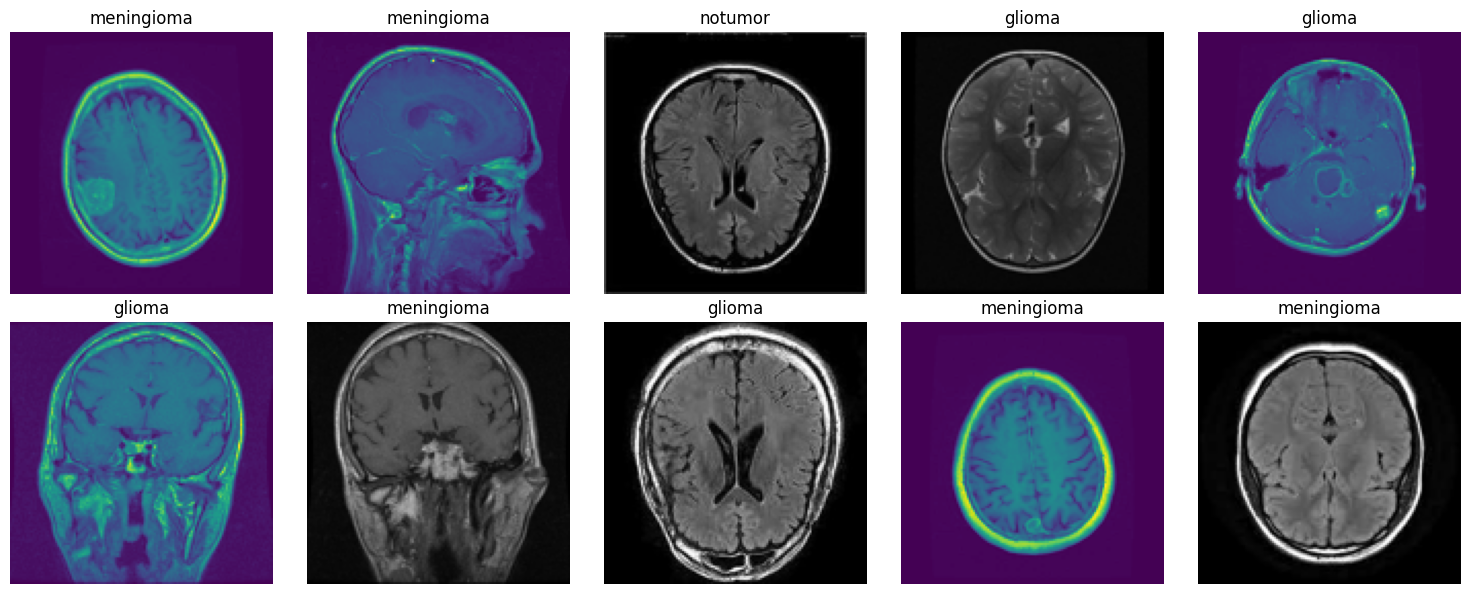

In [ ]:
# Select random index for visualizing the data
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

# Loop through the random indices to display images
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128, 128))

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{train_attributes[idx]}", fontsize=12)

plt.tight_layout()
plt.show()

##Image Preprocessing.




In [ ]:
# Image Augmentation Function
def transform_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))    # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def load_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = transform_image(image)          # ← updated to our function name
        images.append(image)
    return np.array(images)

# Encode labels (Convert label names to integers)
def label_encoder(labels):
    unique_labels = os.listdir(train_set)       # ← fixed: video used 'train_dir', ours is 'train_set'
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def batch_generator(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths  = paths[i:i + batch_size]
            batch_images = load_images(batch_paths)         # ← updated to our function name
            batch_labels = labels[i:i + batch_size]
            batch_labels = label_encoder(batch_labels)      # ← updated to our function name
            yield batch_images, batch_labels

##Model.

In [ ]:
# Force TensorFlow to use GPU
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("GPU configured:", gpus[0])





IMAGE_SIZE = 128

# Build CNN from scratch
model = Sequential()

model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

# Fully connected layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(4, activation='softmax'))

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

model.summary()

# Augmentation — minimal for best results
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True    # ← removed rotation_range and zoom_range
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_set,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=64,
    class_mode='sparse'
)

test_generator = test_datagen.flow_from_directory(
    test_set,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=64,
    class_mode='sparse'
)

print(train_generator.class_indices)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_sparse_categorical_accuracy',
    patience=4,
    restore_best_weights=True
)

epochs = 25

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=test_generator,
    callbacks=[early_stop]
)

# Confirm model is on GPU
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available:", tf.test.is_gpu_available())

# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=test_generator,
    callbacks=[early_stop]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,516,420 (32.49 MB)

 Trainable params: 8,515,972 (32.49 MB)

 Non-trainable params: 448 (1.75 KB)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 434s 5s/step - loss: 1.1740 - sparse_categorical_accuracy: 0.5956 - val_loss: 6.2183 - val_sparse_categorical_accuracy: 0.2288
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 411s 5s/step - loss: 0.5795 - sparse_categorical_accuracy: 0.7649 - val_loss: 9.6206 - val_sparse_categorical_accuracy: 0.2288
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 405s 5s/step - loss: 0.5498 - sparse_categorical_accuracy: 0.7705 - val_loss: 7.5768 - val_sparse_categorical_accuracy: 0.2372
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 409s 5s/step - loss: 0.4473 - sparse_categorical_accuracy: 0.8237 - val_loss: 6.0564 - val_sparse_categorical_accuracy: 0.3776
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 409s 5s/step - loss: 0.4453 - sparse_categorical_accuracy: 0.8194 - val_loss: 2.4690 - val_sparse_categorical_accuracy: 0.5271
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 408s 5s/step - loss: 0.3837 - sparse_categorical_accuracy: 0.8415 - val_loss: 2.8586 - val_sparse_categorical_accuracy: 0.5347
Epoch 7/25

##Accuracy & Loss Plot.

In [ ]:
plt.figure(figsize=(10, 4))
plt.grid(True)

# Training lines
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)

# Validation lines
plt.plot(history.history['val_sparse_categorical_accuracy'], '.b-', linewidth=2)
plt.plot(history.history['val_loss'], '.m-', linewidth=2)

plt.title('Model Training History')
plt.xlabel('Epoch')
plt.xticks([x for x in range(epochs)])
plt.ylim(0, 1.5)   # ← added: caps y-axis so val loss spike doesn't squish the plot
plt.legend(['Train Accuracy', 'Train Loss', 'Val Accuracy', 'Val Loss'],
           loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

##Model Classification Report.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1. Create a fresh test generator — no shuffling, no augmentation
eval_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = eval_datagen.flow_from_directory(
    test_set,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    shuffle=False          # ← critical! keeps labels and predictions aligned
)

# 2. Get predictions
test_predictions = model.predict(eval_generator)
predicted_labels = np.argmax(test_predictions, axis=1)
true_labels = eval_generator.classes

# 3. Class names
class_names = list(eval_generator.class_indices.keys())

# 4. Classification Report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

##Confusion Matrix.

> Add blockquote




In [ ]:
# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

##Saving the Notebook.

In [ ]:
# Save the model to Google Drive
model.save('/content/drive/MyDrive/MRI Images/brain_tumor_cnn.h5')
print("Model saved successfully!")

In [ ]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("TF version:", tf.__version__)

In [ ]:
!nvidia-smi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')